In [1]:
import numpy as np
import pandas as pd
import os
from region_utils import feature_filter_regions
from stats_utils import wilcox_2_samp
import matplotlib.pyplot as plt

from sklearn import model_selection, linear_model, metrics, preprocessing

In [2]:
np.random.seed(42)

### Post-treatment density analysis

In [3]:
cell_type_dir = '../20_300_final_figure_data'
cell_fname = 'registered_post_treatment_cell_types.csv'

cell_frame = pd.read_csv(os.path.join(cell_type_dir, cell_fname))

In [4]:
cell_frame.shape

(8120688, 22)

In [5]:
np.unique(cell_frame['registered_cell_types_post_treatment'])

array(['CD20+', 'CD20+PD1+', 'CD68+', 'CD68+CD163+', 'CD68+CD163+PDL1+',
       'CD68+PDL1+', 'CD8+', 'CD8+PD1+', 'CK+', 'CK+PDL1+',
       'MHCII+CD11c+'], dtype=object)

In [6]:
region_cell_threshold = 100
analysis_type='density'
region_key = 'merged_region_name'
type_key = 'registered_cell_types_post_treatment'

region_path = '../20_300_final_figure_data/density_based_regions.csv'

In [7]:
# only compare pNR and pCR
cell_frame = cell_frame[cell_frame['outcome_response']!='pPR']

In [8]:
# merge CD68+PDL1+ with CD68+CD163+PDL1+
# cell_frame[type_key] = cell_frame[type_key].replace({'CD68+PDL1+': 'CD68+CD163+PDL1+'})

In [9]:
# perform region filtering here
print(f'Filtering regions (Keeping regions with over {region_cell_threshold} cells)')
region_names_to_keep = feature_filter_regions(
    cell_frame, 
    threshold_limit=region_cell_threshold,
    region_key=region_key,
)


Filtering regions (Keeping regions with over 100 cells)
Number of regions passing threshold: 14222


In [10]:
len(np.unique(cell_frame[region_key]))

21913

In [11]:
cell_frame.shape

(7151383, 22)

In [12]:
cell_frame = cell_frame[cell_frame[region_key].isin(region_names_to_keep)]

In [13]:
cell_count_df = cell_frame.pivot_table(
    index='src_image',
    columns=type_key,
    aggfunc='size',
    fill_value=0
).reset_index()

In [14]:
cell_count_df

registered_cell_types_post_treatment,src_image,CD20+,CD20+PD1+,CD68+,CD68+CD163+,CD68+CD163+PDL1+,CD68+PDL1+,CD8+,CD8+PD1+,CK+,CK+PDL1+,MHCII+CD11c+
0,UOP-001,15871,5172,13054,18203,8546,2380,27694,14416,134377,16694,4301
1,UOP-002,2938,796,3978,9121,802,812,5904,749,0,0,4422
2,UOP-003,27361,390,15636,25068,2632,1666,17541,474,0,0,14278
3,UOP-005,6104,1259,2611,5549,987,415,2397,1502,0,0,4434
4,UOP-006,25340,10550,14090,31583,3640,2820,56290,48671,0,0,24955
5,UOP-008,15148,3543,17335,43888,8473,4291,23577,12063,329404,17861,8599
6,UOP-009,79319,14082,33728,71800,9226,13222,114499,39410,0,0,27494
7,UOP-012,51834,12932,41919,46075,4913,6515,63182,32433,0,0,49642
8,UOP-013,48802,10332,70401,85278,27731,28743,68194,47151,445905,89883,15633
9,UOP-015,185151,18002,43736,22535,2663,848,125479,29360,0,0,5037


In [15]:
valid_cell_types = ['CD20+', 'CD20+PD1+', 'CD68+', 'CD68+CD163+', 'CD68+CD163+PDL1+', 'CD68+PDL1+', 'CD8+', 'CD8+PD1+', 'CK+', 'CK+PDL1+', 'MHCII+CD11c+']
# valid_cell_types = ['CD20+', 'CD20+PD1+', 'CD68+', 'CD68+CD163+', 'CD68+CD163+PDL1+', 'CD8+', 'CD8+PD1+', 'CK+', 'CK+PDL1+', 'MHCII+CD11c+']

In [16]:
wsi_count_frame = pd.DataFrame(index=cell_count_df['src_image'].values, data=cell_count_df[valid_cell_types].values, columns=valid_cell_types)

In [17]:
regions_per_sample_series = cell_frame.groupby('src_image')['merged_region_name'].nunique()

In [18]:
exact_um_conversion = 0.4964
exact_mm_conversion = 0.4964/1000
row_size_px = 1000
col_size_px = 1300
height_um = row_size_px*exact_um_conversion
width_um = col_size_px*exact_um_conversion
area_um = height_um*width_um

# this is the area of a single ROI
height_mm = row_size_px*exact_mm_conversion
width_mm = col_size_px*exact_mm_conversion
area_mm = height_mm*width_mm
area_mm

0.320336848

In [19]:
regions_per_sample_series = regions_per_sample_series*area_mm

In [20]:
outcome_mapping = cell_frame[['src_image', 'outcome_response']].drop_duplicates()

In [21]:
wsi_label_series = pd.Series(index=outcome_mapping['src_image'], data=outcome_mapping['outcome_response'].values)
wsi_label_series.value_counts()

pCR    15
pNR     8
Name: count, dtype: int64

In [22]:
wsi_density_frame = wsi_count_frame.div(regions_per_sample_series.values, axis=0)

In [23]:
neg_label = 'pNR'
if neg_label=='non-pCR':
    wsi_label_series = wsi_label_series.replace(['pNR', 'pPR'], ['non-pCR', 'non-pCR'])
    
wsi_stats = wilcox_2_samp(wsi_density_frame, wsi_label_series, group_2_name=neg_label, multi_method=None)

In [24]:
wsi_stats_greater = wilcox_2_samp(wsi_density_frame, wsi_label_series, group_2_name=neg_label, alt_hyp='greater')
wsi_stats_less = wilcox_2_samp(wsi_density_frame, wsi_label_series, group_2_name=neg_label, alt_hyp='less')

p_val_greater = wsi_stats_greater['p_val'].values
p_val_less = wsi_stats_less['p_val'].values

p_vals_combined = np.min(np.concatenate([p_val_greater.reshape(-1,1), p_val_less.reshape(-1,1)], axis=1), axis=1)

wsi_stats_greater['min_p_val'] = p_vals_combined

wsi_stats_greater[['AUC', 'min_p_val']].sort_values(by='AUC', ascending=False)

,AUC,min_p_val
CK+,1.000000,0.000003
CK+PDL1+,1.000000,0.000003
CD68+CD163+PDL1+,0.883333,0.000944
MHCII+CD11c+,0.816667,0.006500
CD20+,0.683333,0.084413
CD68+,0.658333,0.119101
CD68+PDL1+,0.658333,0.119101
CD8+,0.633333,0.162302
CD20+PD1+,0.625000,0.178612
CD8+PD1+,0.625000,0.178612


In [25]:
wsi_stats_greater

,U_stat,U_upper,U_lower,AUC,AUC_upper,AUC_lower,p_val,min_p_val
CD20+,82.0,38.0,82.0,0.683333,0.316667,0.683333,0.084413,0.084413
CD20+PD1+,75.0,45.0,75.0,0.625000,0.375000,0.625000,0.178612,0.178612
CD68+,79.0,41.0,79.0,0.658333,0.341667,0.658333,0.119101,0.119101
CD68+CD163+,64.0,56.0,64.0,0.533333,0.466667,0.533333,0.412589,0.412589
CD68+CD163+PDL1+,14.0,106.0,14.0,0.883333,0.883333,0.116667,0.999292,0.000944
CD68+PDL1+,41.0,79.0,41.0,0.658333,0.658333,0.341667,0.893379,0.119101
CD8+,76.0,44.0,76.0,0.633333,0.366667,0.633333,0.162302,0.162302
CD8+PD1+,75.0,45.0,75.0,0.625000,0.375000,0.625000,0.178612,0.178612
CK+,0.0,120.0,0.0,1.000000,1.000000,0.000000,0.999998,0.000003
CK+PDL1+,0.0,120.0,0.0,1.000000,1.000000,0.000000,0.999998,0.000003


In [26]:
density_copy =  wsi_density_frame.copy()

In [27]:
density_copy.shape

(23, 11)

In [28]:
density_copy.shape

(23, 11)

In [29]:
# use 1200 for on treatment
ymax=1200
ymin=-100
y2_add = 20
y1_add=20
ast_add=20
clipped_ymax=ymax-100

    
density_copy[density_copy.values>clipped_ymax] = clipped_ymax    


In [30]:
prc_sample = 1.00

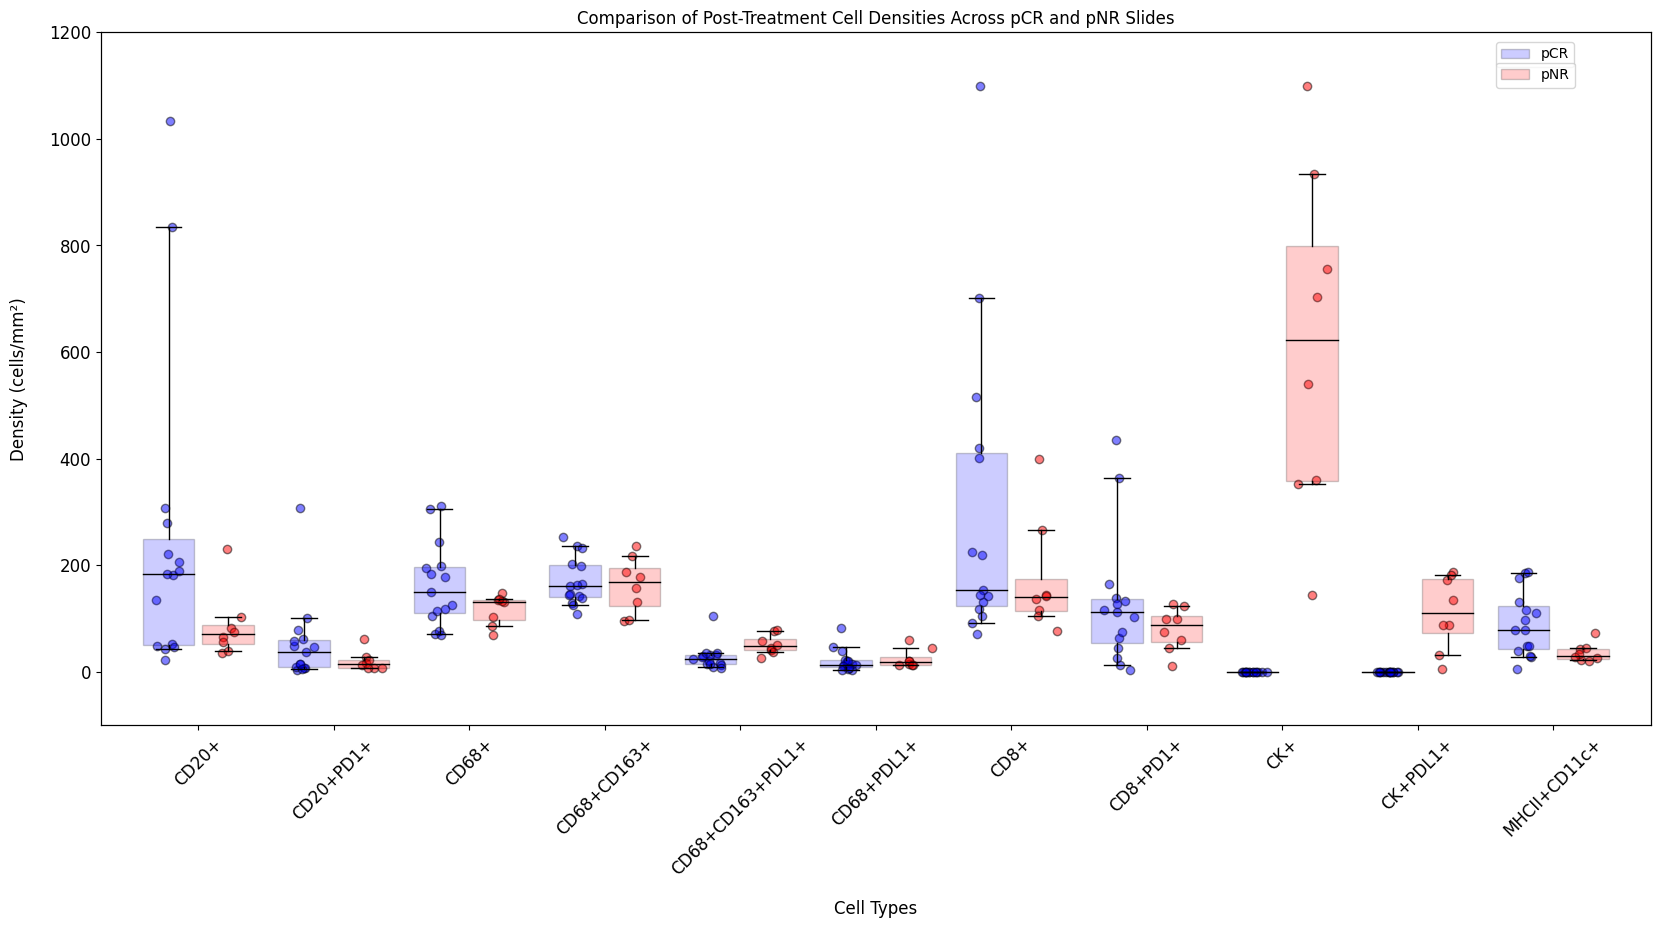

In [31]:
col_list = density_copy.columns.tolist()

fig, ax1 = plt.subplots(figsize=(20,9))

pos_samples = wsi_label_series[wsi_label_series=='pCR'].index.tolist()
neg_samples = wsi_label_series[wsi_label_series==neg_label].index.tolist()

num_groups = len(wsi_density_frame.columns.tolist())
# num_groups=1

box_param = dict(whis=(5, 95), widths=0.38, patch_artist=True,
                 flierprops=dict(marker='', markeredgecolor='black',
                 fillstyle=None), medianprops=dict(color='black'))

pos_frame = density_copy.loc[pos_samples]
neg_frame = density_copy.loc[neg_samples]


space=0.22
# for each category we want to plot the paired results
responder_positions = np.arange(num_groups)-space
non_responder_positions = np.arange(num_groups)+space

ax1.boxplot(pos_frame.values, positions=np.arange(num_groups)-space, boxprops=dict(facecolor='blue', alpha=0.2), **box_param)
# x1_jitter = np.random.normal(i, 0.04, size=len(y))
# ax1.boxplot(pos_frame.values, positions=np.arange(num_groups)-space, boxprops=dict(facecolor='white'), **box_param)
for count, col_name in enumerate(pos_frame.columns.tolist()):
    x_pos = count-space
    col_vals = pos_frame[col_name].values
    x1_jitter = np.random.normal(x_pos, 0.05, size=len(col_vals))
    ax1.scatter(x1_jitter, col_vals, facecolors='blue', edgecolors='k', alpha=0.5)

ax1.set_ylim([ymin, ymax])
ax2 = ax1.twinx()
ax2.boxplot(neg_frame.values, positions=np.arange(num_groups)+space, boxprops=dict(facecolor='red', alpha=0.2), **box_param)
for count, col_name in enumerate(neg_frame.columns.tolist()):
    x_pos = count+space
    col_vals = neg_frame[col_name].values
    x2_jitter = np.random.normal(x_pos, 0.05, size=len(col_vals))
    ax2.scatter(x2_jitter, col_vals, facecolors='red', edgecolors='k', alpha=0.5)
# ax2.boxplot(neg_frame.values, positions=np.arange(num_groups)+space, **box_param)
ax2.set_ylim([ymin, ymax])

# format the p-values here
# x1, x2= 2,3
# y, h, col = max(map(max, region_densities.values)) + 2, 2, 'k'

# format x ticks
labelsize = 12
ax1.set_xticks(np.arange(num_groups))
ax1.set_xticklabels([f'{label}' for label in wsi_density_frame.columns.tolist()], rotation=45)
# ax1.set_xticklabels(['CK+'])

ax1.tick_params(axis='x', labelsize=labelsize)

# format y ticks
yticks_fmt = dict(axis='y', labelsize=labelsize)
ax1.tick_params(**yticks_fmt)
ax2.yaxis.set_ticklabels([])
ax2.yaxis.set_ticks([])

label_fmt = dict(size=12, labelpad=15)
ax1.set_xlabel('Cell Types', **label_fmt)
if analysis_type=='density':
    ax1.set_ylabel('Density (cells/mm\u00b2)', **label_fmt)
    plt.title(f'Comparison of Post-Treatment Cell Densities Across pCR and {neg_label} Slides')

elif analysis_type=='proportion':
    ax1.set_ylabel('Cell Proportions', **label_fmt)
    plt.title(f'Comparison of Post-Treatment Cell Proportions Across pCR and pNR ROIs')
    

ax1.legend(['pCR'], loc=(0.90,0.95))
ax2.legend([f'{neg_label}'], loc=(0.90,0.92))

fig.savefig('figures/post_treatment_density_boxplots.svg', dpi=450, bbox_inches='tight')


plt.show()

### Here perform the logistic regression analysis

In [32]:
filtered_mapping_series = wsi_label_series.loc[wsi_density_frame.index]
filtered_mapping_series.shape

(23,)

In [33]:
data_sample_names = np.array(filtered_mapping_series.index.values)
sample_values = np.array(filtered_mapping_series.values)

In [34]:
sample_mapping = {data_sample_names[sample_index]: sample_values[sample_index] for sample_index in range(len(data_sample_names))}

Fold 0
Dataset shape: (23,)
Fold 1
Dataset shape: (15,)
Fold 2
Dataset shape: (8,)
Train labels:
(array([0., 1.]), array([ 5, 10], dtype=int64))
Test labels:
(array([0., 1.]), array([3, 5], dtype=int64))
Train labels:
(array([0., 1.]), array([ 6, 10], dtype=int64))
Test labels:
(array([0., 1.]), array([2, 5], dtype=int64))
Train labels:
(array([0., 1.]), array([ 5, 10], dtype=int64))
Test labels:
(array([0., 1.]), array([3, 5], dtype=int64))
3-Fold test set accuracy: 0.7391


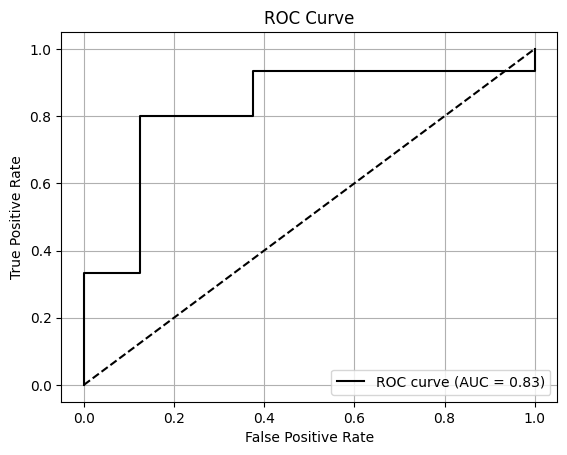

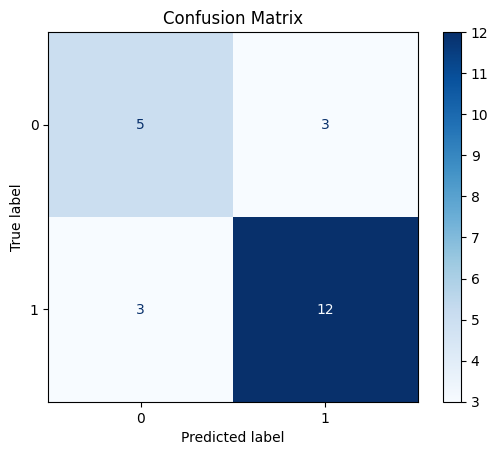

Fold 0
Dataset shape: (23,)
Fold 1
Dataset shape: (15,)
Fold 2
Dataset shape: (8,)
Train labels:
(array([0., 1.]), array([ 5, 10], dtype=int64))
Test labels:
(array([0., 1.]), array([3, 5], dtype=int64))
Train labels:
(array([0., 1.]), array([ 6, 10], dtype=int64))
Test labels:
(array([0., 1.]), array([2, 5], dtype=int64))
Train labels:
(array([0., 1.]), array([ 5, 10], dtype=int64))
Test labels:
(array([0., 1.]), array([3, 5], dtype=int64))
3-Fold test set accuracy: 0.8261


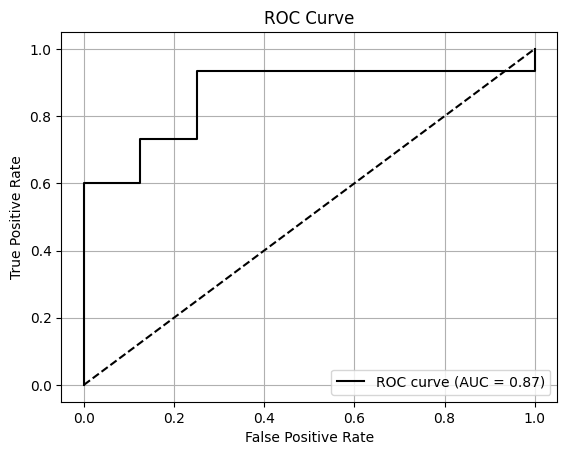

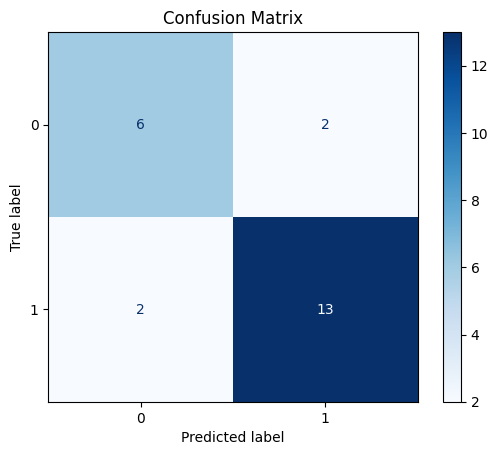

In [35]:
types_to_skip = ['CK+', 'CK+PDL1+']

cell_feature_set = [cell_type for cell_type in wsi_density_frame.columns.tolist() if cell_type not in types_to_skip]
# top_feature_names = ['CD68+CD163+PDL1+', 'MHCII+CD11c+', 'CD68+PDL1+', 'CD20+', 'CD8+']
# top_feature_names = ['CD68+CD163+PDL1+', 'MHCII+CD11c+', 'CD20+', 'CD8+', 'CD68+CD163+']

top_feature_names = ['CD68+CD163+PDL1+', 'MHCII+CD11c+', 'CD20+', 'CD8+', 'CD68+']

feature_lists = [cell_feature_set, top_feature_names]
feature_set_names = ['combined', 'top_5']

for feature_set_index, feature_set in enumerate(feature_lists):
    num_samples = [8,7,7]
    
    test_name_list = []
    
    data_name_copy = np.copy(data_sample_names)
    sample_label_copy = np.copy(sample_values)
    
    for count, sample_num in enumerate(num_samples):
        print(f'Fold {count}')
        print(f'Dataset shape: {data_name_copy.shape}')
    
        if count+1==len(num_samples):
            test_name_list.append(data_name_copy)
            continue
    
        train_names, test_names, train_labels, test_labels = model_selection.train_test_split(data_name_copy, sample_label_copy, test_size=sample_num, stratify=sample_label_copy)

        
        # find indices and drop test names 
        indices_to_keep = ~np.isin(data_name_copy, test_names)
        data_name_copy = data_name_copy[indices_to_keep]
        sample_label_copy = sample_label_copy[indices_to_keep]
        test_name_list.append(test_names)

    # build out the train names too
    train_name_list = []
    for test_set in test_name_list:
        indices_for_training = ~np.isin(data_sample_names, test_set)
        train_name_list.append(data_sample_names[indices_for_training])

    # build out the feature matrices
    density_feature_subset = wsi_density_frame[feature_set]
    label_mapping = {'pNR': 0.00, 'pCR': 1.0}
    final_test_scores = []
    final_test_labels = []
    # record all prediction probabilities for the test set
    for set_index in range(len(train_name_list)):
        train_names = train_name_list[set_index]
        test_names = test_name_list[set_index]
    
        train_features = density_feature_subset.loc[train_names]
        test_features = density_feature_subset.loc[test_names]
        train_arr = np.copy(train_features.values)
        test_arr = np.copy(test_features.values)
    
        train_labels = np.array([sample_mapping[train_name] for train_name in train_names])
        test_labels = np.array([sample_mapping[test_name] for test_name in test_names])
        mapped_train_labels = np.vectorize(label_mapping.get)(train_labels)
        mapped_test_labels = np.vectorize(label_mapping.get)(test_labels)
    
        print(f'Train labels:')
        print(np.unique(mapped_train_labels, return_counts=True))
        print(f'Test labels:')
        print(np.unique(mapped_test_labels, return_counts=True))
    
        scaler = preprocessing.StandardScaler()
        scaler.fit(train_features)
        scaled_train_features = scaler.transform(train_features)
        scaled_test_features = scaler.transform(test_features)
    
        clf = linear_model.LogisticRegression(random_state=0)
        clf.fit(scaled_train_features, mapped_train_labels)
    
        test_probs = clf.predict_proba(scaled_test_features)[:,1]
    
        final_test_scores.append(test_probs)
        final_test_labels.append(mapped_test_labels)

    combined_test_scores = np.concatenate(final_test_scores)
    combined_test_preds = (combined_test_scores>0.50).astype(int)
    combined_test_labels = np.concatenate(final_test_labels)

    accuracy = metrics.accuracy_score(combined_test_labels, combined_test_preds)
    print(f'3-Fold test set accuracy: {accuracy:.4f}')

    num_folds = len(num_samples)
    
    auc_score = metrics.roc_auc_score(combined_test_labels, combined_test_scores)
    end_save_name = 'top_5'
    
    fpr, tpr, _ = metrics.roc_curve(combined_test_labels, combined_test_scores)
    
    # plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, 'k', label=f'ROC curve (AUC = {auc_score:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.savefig(f'figures/lr_{feature_set_names[feature_set_index]}_density_analysis.svg', dpi=450)
    plt.show()
    
    # confusion matrix
    cm = metrics.confusion_matrix(combined_test_labels, combined_test_preds)
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.grid(False)
    plt.show()

### Pre-Treatment density analysis

In [36]:
cell_type_dir = '../20_300_final_figure_data'
cell_fname = 'registered_pre_treatment_cell_types.csv'

cell_frame = pd.read_csv(os.path.join(cell_type_dir, cell_fname))

In [37]:
region_cell_threshold = 0
analysis_type='density'
region_key = 'merged_region_name'
type_key = 'registered_cell_types_pre_treatment'

load_preexisting_regions = False
region_path = ''

In [38]:
# cell_frame[type_key] = cell_frame[type_key].replace({'CD68+PDL1+': 'CD68+CD163+PDL1+'})

In [39]:
# only compare pNR and pCR
cell_frame = cell_frame[cell_frame['outcome_response']!='pPR']

In [40]:
if not load_preexisting_regions:
    # perform region filtering here
    print(f'Filtering regions (Keeping regions with over {region_cell_threshold} cells)')
    region_names_to_keep = feature_filter_regions(
        cell_frame, 
        threshold_limit=region_cell_threshold,
        region_key=region_key,
    )


else:
    print(f'Loading predefined regions...')
    region_names_to_keep = pd.read_csv(os.path.join(region_path))
    region_names_to_keep = np.squeeze(region_names_to_keep.values)


Filtering regions (Keeping regions with over 0 cells)
Number of regions passing threshold: 673


In [41]:
cell_frame = cell_frame[cell_frame[region_key].isin(region_names_to_keep)]

In [42]:
cell_count_df = cell_frame.pivot_table(
    index='src_image',
    columns=type_key,
    aggfunc='size',
    fill_value=0
).reset_index()

In [43]:
valid_cell_types = ['CD20+', 'CD20+PD1+', 'CD68+', 'CD68+CD163+', 'CD68+CD163+PDL1+', 'CD68+PDL1+', 'CD8+', 'CD8+PD1+', 'CK+', 'CK+PDL1+', 'MHCII+CD11c+']
# valid_cell_types = ['CD20+', 'CD20+PD1+', 'CD68+', 'CD68+CD163+', 'CD68+CD163+PDL1+', 'CD8+', 'CD8+PD1+', 'CK+', 'CK+PDL1+', 'MHCII+CD11c+']

In [44]:
wsi_count_frame = pd.DataFrame(index=cell_count_df['src_image'].values, data=cell_count_df[valid_cell_types].values, columns=valid_cell_types)
wsi_count_frame.head()

,CD20+,CD20+PD1+,CD68+,CD68+CD163+,CD68+CD163+PDL1+,CD68+PDL1+,CD8+,CD8+PD1+,CK+,CK+PDL1+,MHCII+CD11c+
UOP-001,6,0,3262,541,118,381,151,14,17820,2319,481
UOP-006,980,92,18203,3397,271,682,1016,1593,40286,746,486
UOP-008,2736,420,16398,4520,3364,1245,2658,3207,19327,2512,3616
UOP-009,5959,2038,5930,7063,361,131,5541,1422,7212,413,4005
UOP-015,34,42,18113,1331,936,3253,450,505,61190,430,1050


In [45]:
regions_per_sample_series = cell_frame.groupby('src_image')['merged_region_name'].nunique()

In [46]:
exact_um_conversion = 0.4964
exact_mm_conversion = 0.4964/1000
row_size_px = 1000
col_size_px = 1300
height_um = row_size_px*exact_um_conversion
width_um = col_size_px*exact_um_conversion
area_um = height_um*width_um

# this is the area of a single ROI
height_mm = row_size_px*exact_mm_conversion
width_mm = col_size_px*exact_mm_conversion
area_mm = height_mm*width_mm
area_mm

0.320336848

In [47]:
regions_per_sample_series = regions_per_sample_series*area_mm

In [48]:
outcome_mapping = cell_frame[['src_image', 'outcome_response']].drop_duplicates()

In [49]:
wsi_label_series = pd.Series(index=outcome_mapping['src_image'], data=outcome_mapping['outcome_response'].values)
wsi_label_series.value_counts()

pCR    7
pNR    4
Name: count, dtype: int64

In [50]:
wsi_density_frame = wsi_count_frame.div(regions_per_sample_series.values, axis=0)

In [51]:
neg_label = 'pNR'
if neg_label=='non-pCR':
    wsi_label_series = wsi_label_series.replace(['pNR', 'pPR'], ['non-pCR', 'non-pCR'])
    
wsi_stats = wilcox_2_samp(wsi_density_frame, wsi_label_series, group_2_name=neg_label, multi_method=None)

In [52]:
wsi_stats_greater = wilcox_2_samp(wsi_density_frame, wsi_label_series, group_2_name=neg_label, alt_hyp='greater')
wsi_stats_less = wilcox_2_samp(wsi_density_frame, wsi_label_series, group_2_name=neg_label, alt_hyp='less')

p_val_greater = wsi_stats_greater['p_val'].values
p_val_less = wsi_stats_less['p_val'].values

p_vals_combined = np.min(np.concatenate([p_val_greater.reshape(-1,1), p_val_less.reshape(-1,1)], axis=1), axis=1)

wsi_stats_greater['min_p_val'] = p_vals_combined

wsi_stats_greater[['AUC', 'min_p_val']].sort_values(by='AUC', ascending=False)

,AUC,min_p_val
CK+PDL1+,0.750000,0.115152
CD20+PD1+,0.571429,0.393939
CD68+,0.571429,0.393939
CD68+CD163+,0.571429,0.393939
CD68+CD163+PDL1+,0.571429,0.393939
CK+,0.571429,0.393939
MHCII+CD11c+,0.571429,0.393939
CD20+,0.535714,0.463636
CD8+,0.535714,0.463636
CD68+PDL1+,0.500000,0.536364


In [53]:
wsi_stats_greater

,U_stat,U_upper,U_lower,AUC,AUC_upper,AUC_lower,p_val,min_p_val
CD20+,13.0,15.0,13.0,0.535714,0.535714,0.464286,0.606061,0.463636
CD20+PD1+,16.0,12.0,16.0,0.571429,0.428571,0.571429,0.393939,0.393939
CD68+,12.0,16.0,12.0,0.571429,0.571429,0.428571,0.675758,0.393939
CD68+CD163+,16.0,12.0,16.0,0.571429,0.428571,0.571429,0.393939,0.393939
CD68+CD163+PDL1+,12.0,16.0,12.0,0.571429,0.571429,0.428571,0.675758,0.393939
CD68+PDL1+,14.0,14.0,14.0,0.500000,0.500000,0.500000,0.536364,0.536364
CD8+,15.0,13.0,15.0,0.535714,0.464286,0.535714,0.463636,0.463636
CD8+PD1+,14.0,14.0,14.0,0.500000,0.500000,0.500000,0.536364,0.536364
CK+,16.0,12.0,16.0,0.571429,0.428571,0.571429,0.393939,0.393939
CK+PDL1+,7.0,21.0,7.0,0.750000,0.750000,0.250000,0.918182,0.115152


In [54]:
density_copy =  wsi_density_frame.copy()

In [55]:
# use 1200 for on treatment
ymax=1750
ymin=-100
y2_add = 20
y1_add=20
ast_add=20
clipped_ymax=ymax-100

    
density_copy[density_copy.values>clipped_ymax] = clipped_ymax    


In [56]:
prc_sample = 1.00

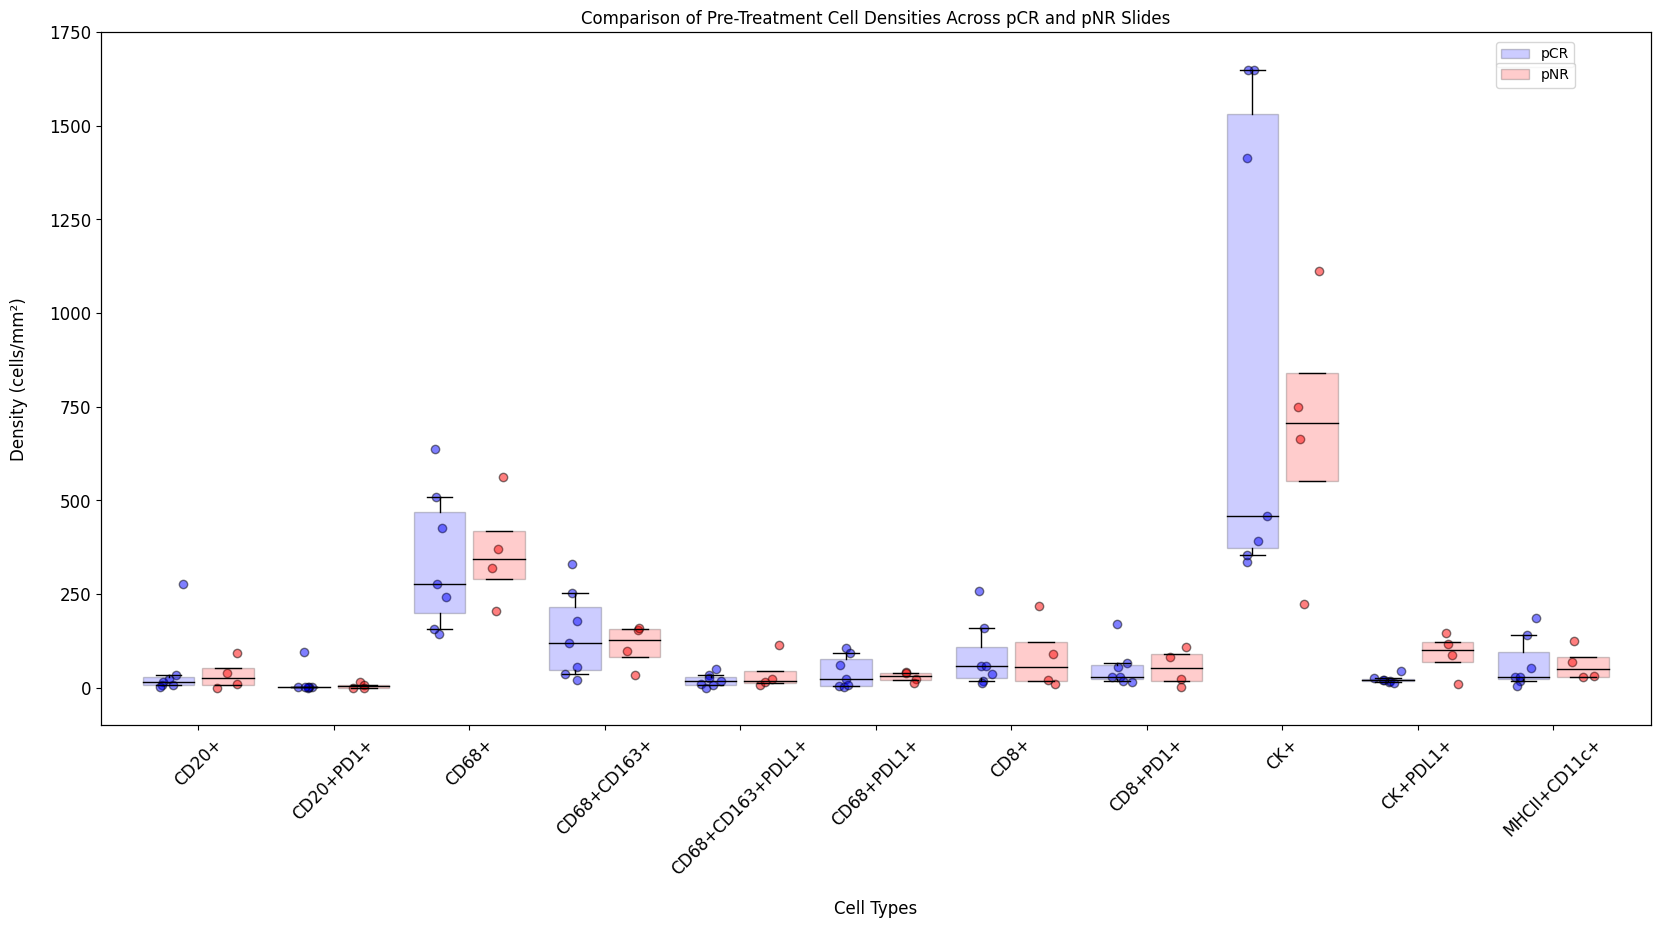

In [57]:
col_list = density_copy.columns.tolist()

fig, ax1 = plt.subplots(figsize=(20,9))

pos_samples = wsi_label_series[wsi_label_series=='pCR'].index.tolist()
neg_samples = wsi_label_series[wsi_label_series==neg_label].index.tolist()

num_groups = len(wsi_density_frame.columns.tolist())
# num_groups=1

box_param = dict(whis=(5, 95), widths=0.38, patch_artist=True,
                 flierprops=dict(marker='', markeredgecolor='black',
                 fillstyle=None), medianprops=dict(color='black'))

pos_frame = density_copy.loc[pos_samples]
neg_frame = density_copy.loc[neg_samples]


space=0.22
# for each category we want to plot the paired results
responder_positions = np.arange(num_groups)-space
non_responder_positions = np.arange(num_groups)+space

ax1.boxplot(pos_frame.values, positions=np.arange(num_groups)-space, boxprops=dict(facecolor='blue', alpha=0.2), **box_param)
# x1_jitter = np.random.normal(i, 0.04, size=len(y))
# ax1.boxplot(pos_frame.values, positions=np.arange(num_groups)-space, boxprops=dict(facecolor='white'), **box_param)
for count, col_name in enumerate(pos_frame.columns.tolist()):
    x_pos = count-space
    col_vals = pos_frame[col_name].values
    x1_jitter = np.random.normal(x_pos, 0.05, size=len(col_vals))
    ax1.scatter(x1_jitter, col_vals, facecolors='blue', edgecolors='k', alpha=0.5)

ax1.set_ylim([ymin, ymax])
ax2 = ax1.twinx()
ax2.boxplot(neg_frame.values, positions=np.arange(num_groups)+space, boxprops=dict(facecolor='red', alpha=0.2), **box_param)
for count, col_name in enumerate(neg_frame.columns.tolist()):
    x_pos = count+space
    col_vals = neg_frame[col_name].values
    x2_jitter = np.random.normal(x_pos, 0.05, size=len(col_vals))
    ax2.scatter(x2_jitter, col_vals, facecolors='red', edgecolors='k', alpha=0.5)
# ax2.boxplot(neg_frame.values, positions=np.arange(num_groups)+space, **box_param)
ax2.set_ylim([ymin, ymax])

# format the p-values here
# x1, x2= 2,3
# y, h, col = max(map(max, region_densities.values)) + 2, 2, 'k'

# format x ticks
labelsize = 12
ax1.set_xticks(np.arange(num_groups))
ax1.set_xticklabels([f'{label}' for label in wsi_density_frame.columns.tolist()], rotation=45)
# ax1.set_xticklabels(['CK+'])

ax1.tick_params(axis='x', labelsize=labelsize)

# format y ticks
yticks_fmt = dict(axis='y', labelsize=labelsize)
ax1.tick_params(**yticks_fmt)
ax2.yaxis.set_ticklabels([])
ax2.yaxis.set_ticks([])

label_fmt = dict(size=12, labelpad=15)
ax1.set_xlabel('Cell Types', **label_fmt)
if analysis_type=='density':
    ax1.set_ylabel('Density (cells/mm\u00b2)', **label_fmt)
    plt.title(f'Comparison of Pre-Treatment Cell Densities Across pCR and {neg_label} Slides')

elif analysis_type=='proportion':
    ax1.set_ylabel('Cell Proportions', **label_fmt)
    plt.title(f'Comparison of Pre-Treatment Cell Proportions Across pCR and pNR ROIs')
    

ax1.legend(['pCR'], loc=(0.90,0.95))
ax2.legend([f'{neg_label}'], loc=(0.90,0.92))

fig.savefig('figures/pre_treatment_density_boxplots.svg', dpi=450, bbox_inches='tight')

plt.show()